# WSEI Deep Learning – Lab 07

**Zadanie 1:** Graph Neural Networks (GCN) – klasyfikacja grafów (Mutagenicity) i węzłów (Actor), eksperyment głębokości 1–8 warstw.

**Zadanie 2:** Spiking Neural Networks (snnTorch) – klasyfikacja FashionMNIST i CIFAR-10.

Materiały:
- [PyG – Graph Classification](https://colab.research.google.com/drive/1I8a0DfQ3fI7Njc62__mVXUlcAleUclnb?usp=sharing)
- [PyG – Node Classification](https://colab.research.google.com/drive/14OvFnAXggxB8vM4e8vSURUp1TaKnovzX?usp=sharing)
- [snnTorch Tutorial 5](https://snntorch.readthedocs.io/en/latest/tutorials/tutorial_5.html)


In [ ]:
# Instalacja zależności (odkomentuj w środowisku bez PyG / snnTorch)
# %pip install torch-geometric snntorch


In [1]:
# Ustaw True do szybkiego testu (mniej epok); False do pełnego eksperymentu
FAST_MODE = False

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.nn import Linear
from torch_geometric.datasets import TUDataset, Actor
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Urządzenie:", device)


c:\Users\mateu\Desktop\dyplom\nlp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Urządzenie: cuda


## Zadanie 1 – Graph Neural Network (GCN)

Implementacja prostego modelu **GCN** o zmiennej liczbie warstw konwolucyjnych (1–8).
- **Mutagenicity** (`TUDataset`) – klasyfikacja całych grafów (readout: `global_mean_pool`)
- **Actor** – klasyfikacja węzłów w jednym grafie społecznościowym (maski train/val/test, split 0)


In [2]:
class GraphGCN(torch.nn.Module):
    """GCN do klasyfikacji grafów (N warstw GCNConv + pooling + Linear)."""

    def __init__(self, in_channels, hidden_channels, num_layers, num_classes, dropout=0.5):
        super().__init__()
        if num_layers < 1:
            raise ValueError("num_layers musi być >= 1")
        self.convs = torch.nn.ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
        if num_layers > 1:
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
        self.dropout = dropout
        self.lin = Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.lin(x)


class NodeGCN(torch.nn.Module):
    """GCN do klasyfikacji węzłów (N warstw, ostatnia warstwa -> num_classes)."""

    def __init__(self, in_channels, hidden_channels, num_layers, num_classes, dropout=0.5):
        super().__init__()
        if num_layers < 1:
            raise ValueError("num_layers musi być >= 1")
        self.convs = torch.nn.ModuleList()
        if num_layers == 1:
            self.convs.append(GCNConv(in_channels, num_classes))
        else:
            self.convs.append(GCNConv(in_channels, hidden_channels))
            for _ in range(num_layers - 2):
                self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.convs.append(GCNConv(hidden_channels, num_classes))
        self.dropout = dropout

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return x


In [3]:
@torch.no_grad()
def graph_accuracy(loader, model):
    model.eval()
    correct = 0
    for data in loader:
        data = data.to(device)
        pred = model(data.x, data.edge_index, data.batch).argmax(dim=1)
        correct += int((pred == data.y).sum())
    return correct / len(loader.dataset)


def train_graph_classifier(train_loader, val_loader, model, optimizer, epochs):
    history = {"train_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data.x, data.edge_index, data.batch)
            loss = F.cross_entropy(out, data.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * data.num_graphs
        train_loss = total_loss / len(train_loader.dataset)
        train_acc = graph_accuracy(train_loader, model)
        val_acc = graph_accuracy(val_loader, model)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}")
    return history


@torch.no_grad()
def node_accuracy(data, model, mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out[mask].argmax(dim=1)
    return float((pred == data.y[mask]).sum() / mask.sum())


def train_node_classifier(data, model, optimizer, epochs, train_mask, val_mask):
    history = {"train_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[train_mask], data.y[train_mask])
        loss.backward()
        optimizer.step()
        train_acc = node_accuracy(data, model, train_mask)
        val_acc = node_accuracy(data, model, val_mask)
        history["train_loss"].append(loss.item())
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        if epoch % 50 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | loss={loss.item():.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}")
    return history


### 1.1 Mutagenicity – klasyfikacja grafów

In [4]:
mutag = TUDataset(root="data/TUDataset", name="Mutagenicity")
mutag = mutag.shuffle()
n = len(mutag)
train_n = int(0.8 * n)
val_n = int(0.1 * n)
train_ds = mutag[:train_n]
val_ds = mutag[train_n : train_n + val_n]
test_ds = mutag[train_n + val_n :]

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

print(mutag)
print(f"Grafów: {n}, cechy węzła: {mutag.num_features}, klas: {mutag.num_classes}")
print(f"Train/val/test: {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")


Mutagenicity(4337)
Grafów: 4337, cechy węzła: 14, klas: 2
Train/val/test: 3469/433/435


In [5]:
GRAPH_EPOCHS = 15 if FAST_MODE else 100
GRAPH_HIDDEN = 64
GRAPH_LAYERS = list(range(1, 9))

mutag_results = []
for num_layers in GRAPH_LAYERS:
    print(f"\n=== Mutagenicity | warstwy GCN: {num_layers} ===")
    model = GraphGCN(mutag.num_features, GRAPH_HIDDEN, num_layers, mutag.num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    history = train_graph_classifier(train_loader, val_loader, model, optimizer, GRAPH_EPOCHS)
    test_acc = graph_accuracy(test_loader, model)
    best_val = max(history["val_acc"])
    mutag_results.append({
        "layers": num_layers,
        "test_acc": test_acc,
        "best_val_acc": best_val,
        "final_train_acc": history["train_acc"][-1],
    })
    print(f"Najlepsza val_acc={best_val:.4f}, test_acc={test_acc:.4f}")

mutag_df_layers = [r["layers"] for r in mutag_results]
mutag_df_test = [r["test_acc"] for r in mutag_results]



=== Mutagenicity | warstwy GCN: 1 ===
Epoch 001 | loss=0.6664 | train_acc=0.6498 | val_acc=0.6582
Epoch 020 | loss=0.6264 | train_acc=0.6604 | val_acc=0.6490
Epoch 040 | loss=0.6209 | train_acc=0.6604 | val_acc=0.6490
Epoch 060 | loss=0.6202 | train_acc=0.6642 | val_acc=0.6374
Epoch 080 | loss=0.6222 | train_acc=0.6523 | val_acc=0.6420
Epoch 100 | loss=0.6206 | train_acc=0.6633 | val_acc=0.6467
Najlepsza val_acc=0.6674, test_acc=0.6713

=== Mutagenicity | warstwy GCN: 2 ===
Epoch 001 | loss=0.6489 | train_acc=0.6823 | val_acc=0.6559
Epoch 020 | loss=0.5699 | train_acc=0.6875 | val_acc=0.7044
Epoch 040 | loss=0.5731 | train_acc=0.7138 | val_acc=0.7182
Epoch 060 | loss=0.5571 | train_acc=0.7342 | val_acc=0.7298
Epoch 080 | loss=0.5509 | train_acc=0.7437 | val_acc=0.7206
Epoch 100 | loss=0.5445 | train_acc=0.7285 | val_acc=0.7367
Najlepsza val_acc=0.7529, test_acc=0.7379

=== Mutagenicity | warstwy GCN: 3 ===
Epoch 001 | loss=0.6503 | train_acc=0.7014 | val_acc=0.6697
Epoch 020 | loss=0.

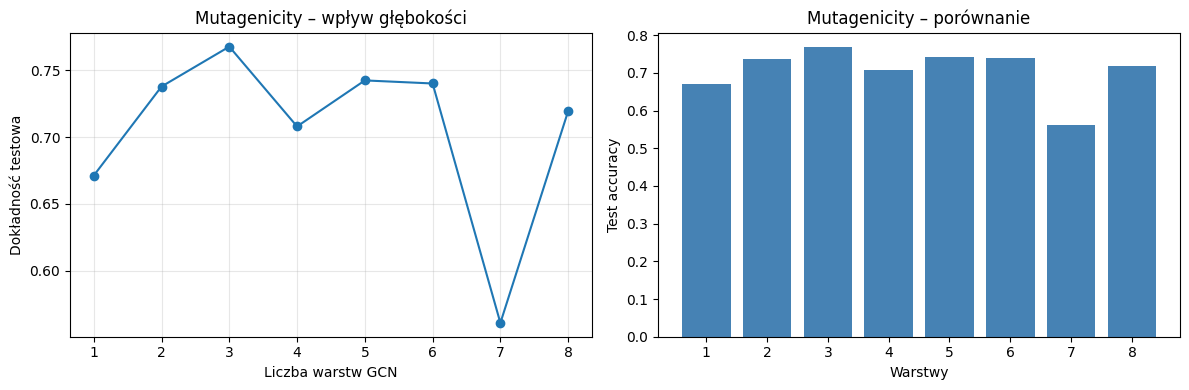

{'layers': 1, 'test_acc': 0.671264367816092, 'best_val_acc': 0.6674364896073903, 'final_train_acc': 0.6633035456904007}
{'layers': 2, 'test_acc': 0.7379310344827587, 'best_val_acc': 0.7528868360277137, 'final_train_acc': 0.7284520034592101}
{'layers': 3, 'test_acc': 0.767816091954023, 'best_val_acc': 0.8083140877598153, 'final_train_acc': 0.7702507927356587}
{'layers': 4, 'test_acc': 0.7080459770114943, 'best_val_acc': 0.7736720554272517, 'final_train_acc': 0.7515134044393197}
{'layers': 5, 'test_acc': 0.7425287356321839, 'best_val_acc': 0.76905311778291, 'final_train_acc': 0.7584318247333526}
{'layers': 6, 'test_acc': 0.7402298850574712, 'best_val_acc': 0.7806004618937644, 'final_train_acc': 0.7667915825886422}
{'layers': 7, 'test_acc': 0.5609195402298851, 'best_val_acc': 0.5635103926096998, 'final_train_acc': 0.5514557509368694}
{'layers': 8, 'test_acc': 0.7195402298850575, 'best_val_acc': 0.7505773672055427, 'final_train_acc': 0.7428653790717786}


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(mutag_df_layers, mutag_df_test, marker="o")
ax[0].set_xlabel("Liczba warstw GCN")
ax[0].set_ylabel("Dokładność testowa")
ax[0].set_title("Mutagenicity – wpływ głębokości")
ax[0].grid(True, alpha=0.3)

ax[1].bar([str(r["layers"]) for r in mutag_results], mutag_df_test, color="steelblue")
ax[1].set_xlabel("Warstwy")
ax[1].set_ylabel("Test accuracy")
ax[1].set_title("Mutagenicity – porównanie")
plt.tight_layout()
plt.show()

for r in mutag_results:
    print(r)


### 1.2 Actor – klasyfikacja węzłów

Dataset [Actor](https://pytorch-geometric.readthedocs.io/en/2.6.0/generated/torch_geometric.datasets.Actor.html) zawiera 10 podziałów train/val/test – używamy **split=0**.


In [7]:
actor_ds = Actor(root="data/Actor")
actor_data = actor_ds[0]
SPLIT = 0
train_mask = actor_data.train_mask[:, SPLIT].bool()
val_mask = actor_data.val_mask[:, SPLIT].bool()
test_mask = actor_data.test_mask[:, SPLIT].bool()
actor_data = actor_data.to(device)

print(actor_ds)
print(f"Węzły: {actor_data.num_nodes}, cechy: {actor_data.num_features}, klas: {actor_ds.num_classes}")
print(f"Train/val/test: {train_mask.sum().item()}/{val_mask.sum().item()}/{test_mask.sum().item()}")


Actor()
Węzły: 7600, cechy: 932, klas: 5
Train/val/test: 3648/2432/1520


In [8]:
NODE_EPOCHS = 50 if FAST_MODE else 300
NODE_HIDDEN = 128
NODE_LAYERS = list(range(1, 9))

actor_results = []
for num_layers in NODE_LAYERS:
    print(f"\n=== Actor | warstwy GCN: {num_layers} ===")
    model = NodeGCN(actor_data.num_features, NODE_HIDDEN, num_layers, actor_ds.num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    history = train_node_classifier(actor_data, model, optimizer, NODE_EPOCHS, train_mask, val_mask)
    test_acc = node_accuracy(actor_data, model, test_mask)
    best_val = max(history["val_acc"])
    actor_results.append({
        "layers": num_layers,
        "test_acc": test_acc,
        "best_val_acc": best_val,
        "final_train_acc": history["train_acc"][-1],
    })
    print(f"Najlepsza val_acc={best_val:.4f}, test_acc={test_acc:.4f}")

actor_df_layers = [r["layers"] for r in actor_results]
actor_df_test = [r["test_acc"] for r in actor_results]



=== Actor | warstwy GCN: 1 ===
Epoch 001 | loss=1.6001 | train_acc=0.2681 | val_acc=0.2549
Epoch 050 | loss=1.3382 | train_acc=0.4825 | val_acc=0.2989
Epoch 100 | loss=1.3121 | train_acc=0.4899 | val_acc=0.3047
Epoch 150 | loss=1.3073 | train_acc=0.4937 | val_acc=0.3047
Epoch 200 | loss=1.3059 | train_acc=0.4948 | val_acc=0.3047
Epoch 250 | loss=1.3055 | train_acc=0.4937 | val_acc=0.3059
Epoch 300 | loss=1.3053 | train_acc=0.4953 | val_acc=0.3072
Najlepsza val_acc=0.3072, test_acc=0.3013

=== Actor | warstwy GCN: 2 ===
Epoch 001 | loss=1.5985 | train_acc=0.2815 | val_acc=0.2611
Epoch 050 | loss=0.9635 | train_acc=0.6902 | val_acc=0.2599
Epoch 100 | loss=0.7950 | train_acc=0.7733 | val_acc=0.2525
Epoch 150 | loss=0.7218 | train_acc=0.8161 | val_acc=0.2533
Epoch 200 | loss=0.6786 | train_acc=0.8416 | val_acc=0.2558
Epoch 250 | loss=0.6493 | train_acc=0.8544 | val_acc=0.2500
Epoch 300 | loss=0.6402 | train_acc=0.8629 | val_acc=0.2529
Najlepsza val_acc=0.3104, test_acc=0.2480

=== Actor |

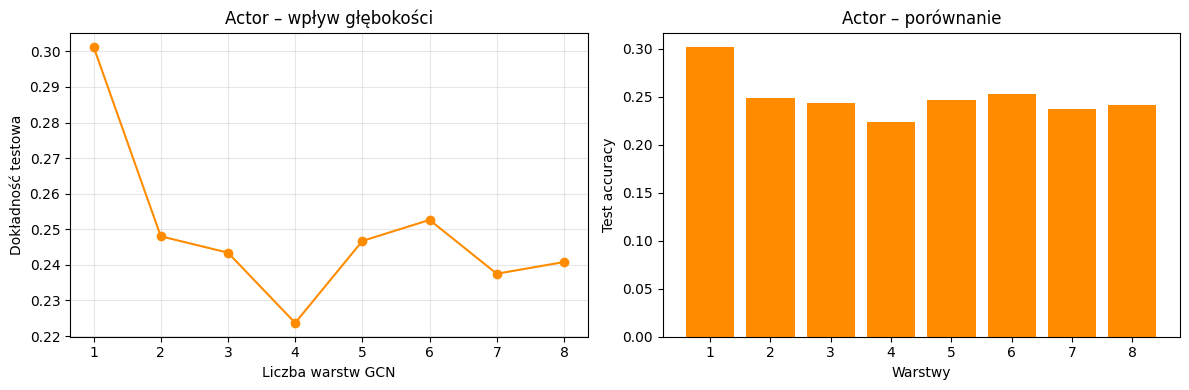

{'layers': 1, 'test_acc': 0.3013158142566681, 'best_val_acc': 0.3071545958518982, 'final_train_acc': 0.49533993005752563}
{'layers': 2, 'test_acc': 0.24802632629871368, 'best_val_acc': 0.31044408679008484, 'final_train_acc': 0.8629385828971863}
{'layers': 3, 'test_acc': 0.2434210628271103, 'best_val_acc': 0.2861842215061188, 'final_train_acc': 0.8769188523292542}
{'layers': 4, 'test_acc': 0.22368422150611877, 'best_val_acc': 0.28330591320991516, 'final_train_acc': 0.8314144611358643}
{'layers': 5, 'test_acc': 0.24671053886413574, 'best_val_acc': 0.2800164520740509, 'final_train_acc': 0.6450109481811523}
{'layers': 6, 'test_acc': 0.25263160467147827, 'best_val_acc': 0.28577303886413574, 'final_train_acc': 0.4583333432674408}
{'layers': 7, 'test_acc': 0.23750001192092896, 'best_val_acc': 0.2787829041481018, 'final_train_acc': 0.44572368264198303}
{'layers': 8, 'test_acc': 0.2407894879579544, 'best_val_acc': 0.27672696113586426, 'final_train_acc': 0.41365131735801697}


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(actor_df_layers, actor_df_test, marker="o", color="darkorange")
ax[0].set_xlabel("Liczba warstw GCN")
ax[0].set_ylabel("Dokładność testowa")
ax[0].set_title("Actor – wpływ głębokości")
ax[0].grid(True, alpha=0.3)

ax[1].bar([str(r["layers"]) for r in actor_results], actor_df_test, color="darkorange")
ax[1].set_xlabel("Warstwy")
ax[1].set_ylabel("Test accuracy")
ax[1].set_title("Actor – porównanie")
plt.tight_layout()
plt.show()

for r in actor_results:
    print(r)


### 1.3 Wnioski (głębokość GCN)

Przy bardzo głębokich GCN (6–8 warstw) często obserwuje się **oversmoothing** – reprezentacje węzłów stają się zbyt podobne i dokładność spada. Płytsze sieci (2–4 warstwy) zwykle dają najlepszy kompromis na Mutagenicity i Actor.


---

## Zadanie 2 – Spiking Neural Network (snnTorch)

Implementacja wg [Tutorial 5](https://snntorch.readthedocs.io/en/latest/tutorials/tutorial_5.html):
- neurony LIF (`snn.Leaky`) + **surrogate gradient** (ATan),
- uczenie **BPTT** (suma strat po krokach czasowych),
- dekodowanie wyjścia: **rate coding** (liczba spike'ów).


In [10]:
import snntorch as snn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


In [19]:
class SNNFCN(nn.Module):
    """W pełni połączona sieć SNN (Tutorial 5)."""

    def __init__(self, num_inputs, num_hidden, num_outputs, beta=0.95):
        super().__init__()
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(num_hidden, num_hidden)
        self.lif2 = snn.Leaky(beta=beta)
        self.fc3 = nn.Linear(num_hidden, num_outputs)
        self.lif3 = snn.Leaky(beta=beta)

    def forward(self, x, num_steps):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        spk3_rec = []
        mem3_rec = []
        for _ in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.fc3(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)
            spk3_rec.append(spk3)
            mem3_rec.append(mem3)
        return torch.stack(spk3_rec), torch.stack(mem3_rec)


def snn_batch_accuracy(data, targets, net, num_steps):
    spk, _ = net(data, num_steps)
    _, idx = spk.sum(dim=0).max(1)
    return (idx == targets).float().mean().item()


def train_snn(net, train_loader, test_loader, num_steps, num_epochs, lr=1e-3, device=device):
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, betas=(0.9, 0.999))
    loss_fn = nn.CrossEntropyLoss()
    train_loss_hist, test_loss_hist, test_acc_hist = [], [], []

    for epoch in range(num_epochs):
        net.train()
        running_loss = 0.0
        for data, targets in train_loader:
            data = data.view(data.size(0), -1).to(device)
            targets = targets.to(device)
            spk, mem = net(data, num_steps)
            loss = sum(loss_fn(mem[t], targets) for t in range(num_steps))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        net.eval()
        test_loss = torch.zeros(1, device=device)
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for data, targets in test_loader:
                data = data.view(data.size(0), -1).to(device)
                targets = targets.to(device)
                spk, mem = net(data, num_steps)
                test_loss += sum(loss_fn(mem[t], targets) for t in range(num_steps))
                pred = spk.sum(dim=0).max(1)[1]
                test_correct += (pred == targets).sum().item()
                test_total += targets.numel()

        train_loss_hist.append(running_loss / len(train_loader))
        test_loss_hist.append(test_loss.item() / len(test_loader))
        test_acc = test_correct / test_total
        test_acc_hist.append(test_acc)
        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"train_loss={train_loss_hist[-1]:.2f} | test_loss={test_loss_hist[-1]:.2f} | test_acc={test_acc:.4f}"
        )

    return train_loss_hist, test_loss_hist, test_acc_hist


### 2.1 FashionMNIST

In [14]:
SNN_NUM_STEPS = 25
SNN_BATCH = 128
SNN_EPOCHS = 2 if FAST_MODE else 10

fashion_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

fashion_train = datasets.FashionMNIST("./data", train=True, download=True, transform=fashion_transform)
fashion_test = datasets.FashionMNIST("./data", train=False, download=True, transform=fashion_transform)
fashion_train_loader = DataLoader(fashion_train, batch_size=SNN_BATCH, shuffle=True, drop_last=True)
fashion_test_loader = DataLoader(fashion_test, batch_size=SNN_BATCH, shuffle=False, drop_last=False)

fashion_net = SNNFCN(28 * 28, 1000, 10, beta=0.95).to(device)
fashion_loss, fashion_test_loss, fashion_acc = train_snn(
    fashion_net, fashion_train_loader, fashion_test_loader, SNN_NUM_STEPS, SNN_EPOCHS, lr=5e-4, device=device
)


Epoch 01/10 | train_loss=16.49 | test_loss=14.75 | test_acc=0.6849
Epoch 02/10 | train_loss=12.94 | test_loss=13.10 | test_acc=0.7766
Epoch 03/10 | train_loss=11.66 | test_loss=12.81 | test_acc=0.8008
Epoch 04/10 | train_loss=10.90 | test_loss=12.45 | test_acc=0.8408
Epoch 05/10 | train_loss=10.16 | test_loss=11.80 | test_acc=0.8427
Epoch 06/10 | train_loss=9.51 | test_loss=11.27 | test_acc=0.8419
Epoch 07/10 | train_loss=9.16 | test_loss=12.44 | test_acc=0.8489
Epoch 08/10 | train_loss=8.70 | test_loss=11.38 | test_acc=0.8417
Epoch 09/10 | train_loss=8.48 | test_loss=11.86 | test_acc=0.8619
Epoch 10/10 | train_loss=8.11 | test_loss=11.48 | test_acc=0.8496


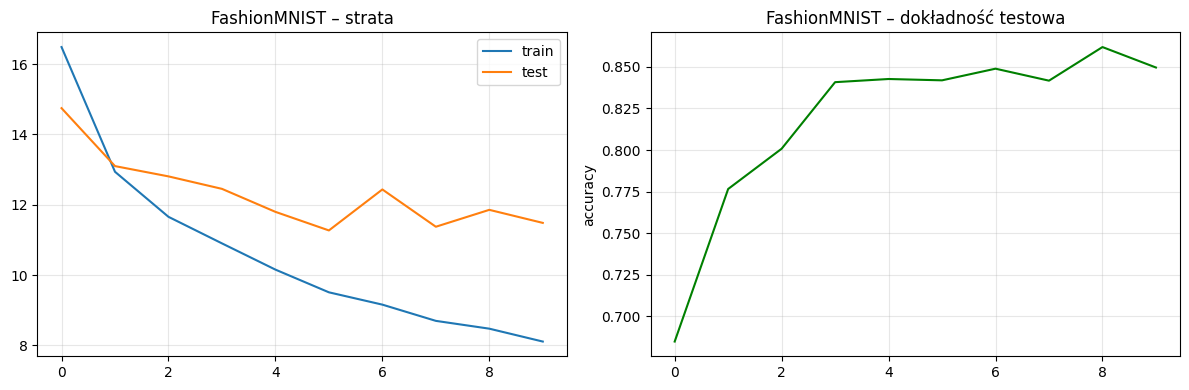

Końcowa dokładność FashionMNIST: 84.96%


In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(fashion_loss, label="train")
ax[0].plot(fashion_test_loss, label="test")
ax[0].set_title("FashionMNIST – strata")
ax[0].legend()
ax[0].grid(True, alpha=0.3)
ax[1].plot(fashion_acc, color="green")
ax[1].set_title("FashionMNIST – dokładność testowa")
ax[1].set_ylabel("accuracy")
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Końcowa dokładność FashionMNIST: {fashion_acc[-1] * 100:.2f}%")


### 2.2 CIFAR-10

In [20]:
cifar_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

cifar_train = datasets.CIFAR10("./data", train=True, download=True, transform=cifar_transform)
cifar_test = datasets.CIFAR10("./data", train=False, download=True, transform=cifar_transform)
cifar_train_loader = DataLoader(cifar_train, batch_size=64, shuffle=True, drop_last=True)
cifar_test_loader = DataLoader(cifar_test, batch_size=64, shuffle=False, drop_last=False)

# Mniejsza sieć ze względu na 3072 wejścia (3x32x32)
cifar_epochs = 3 if FAST_MODE else 15
cifar_net = SNNFCN(3 * 32 * 32, 512, 10, beta=0.95).to(device)
cifar_loss, cifar_test_loss, cifar_acc = train_snn(
    cifar_net, cifar_train_loader, cifar_test_loader, num_steps=25, num_epochs=cifar_epochs, lr=5e-4, device=device
)


Epoch 01/15 | train_loss=45.20 | test_loss=42.20 | test_acc=0.4612
Epoch 02/15 | train_loss=41.26 | test_loss=41.75 | test_acc=0.4659
Epoch 03/15 | train_loss=39.85 | test_loss=41.12 | test_acc=0.4728
Epoch 04/15 | train_loss=38.74 | test_loss=40.35 | test_acc=0.4892
Epoch 05/15 | train_loss=37.88 | test_loss=40.71 | test_acc=0.4833
Epoch 06/15 | train_loss=37.36 | test_loss=40.79 | test_acc=0.4882
Epoch 07/15 | train_loss=36.42 | test_loss=40.49 | test_acc=0.4967
Epoch 08/15 | train_loss=35.73 | test_loss=40.67 | test_acc=0.4985
Epoch 09/15 | train_loss=35.01 | test_loss=42.27 | test_acc=0.4985
Epoch 10/15 | train_loss=34.51 | test_loss=41.32 | test_acc=0.5006
Epoch 11/15 | train_loss=33.84 | test_loss=41.80 | test_acc=0.4975
Epoch 12/15 | train_loss=33.30 | test_loss=41.57 | test_acc=0.4999
Epoch 13/15 | train_loss=32.82 | test_loss=42.61 | test_acc=0.4969
Epoch 14/15 | train_loss=32.33 | test_loss=43.55 | test_acc=0.5041
Epoch 15/15 | train_loss=31.78 | test_loss=43.31 | test_acc=0.

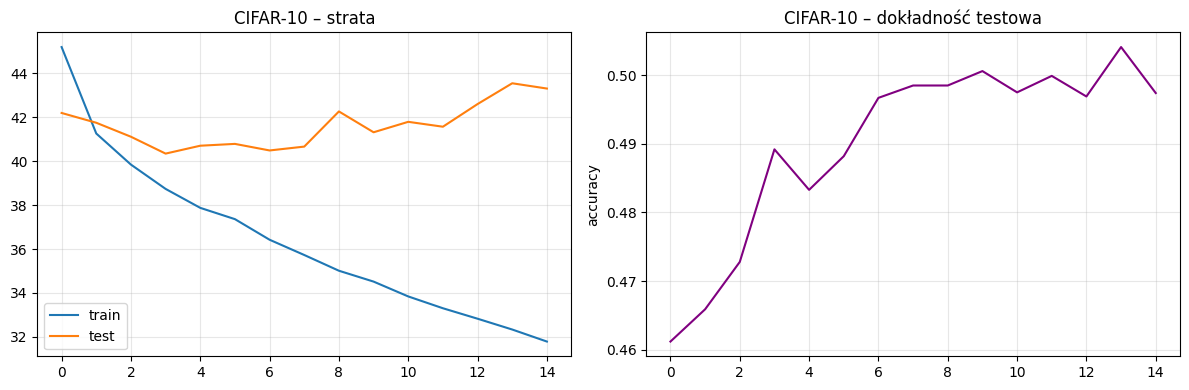

Końcowa dokładność CIFAR-10: 49.74%


In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(cifar_loss, label="train")
ax[0].plot(cifar_test_loss, label="test")
ax[0].set_title("CIFAR-10 – strata")
ax[0].legend()
ax[0].grid(True, alpha=0.3)
ax[1].plot(cifar_acc, color="purple")
ax[1].set_title("CIFAR-10 – dokładność testowa")
ax[1].set_ylabel("accuracy")
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Końcowa dokładność CIFAR-10: {cifar_acc[-1] * 100:.2f}%")


### 2.3 Podsumowanie SNN

- Statyczne piksele są kodowane jako stały prąd wejściowy do LIF przez `num_steps` kroków (BPTT).
- Klasa przewidywana na podstawie **największej liczby spike'ów** w warstwie wyjściowej.
- CIFAR-10 jest trudniejszy dla FCN-SNN niż FashionMNIST; lepsze wyniki daje architektura konwolucyjna (Tutorial 6 snnTorch).
- CIFAR-10: zmiana architektury sieci (FCN → CNN-SNN) nie poprawiła wyników klasyfikacji w porównaniu z modelem w pełni połączonym; dokładność testowa pozostała na podobnym poziomie (~48–50%).
